# Mutual Fund Analytics: Day 4 Performance Analytics & Scorecard

This notebook contains the trailing returns calculations, risk-adjusted performance ratios, linear regression analysis, maximum drawdown indicators, and the composite Fund Scorecard (0-100) for all 40 schemes.

### Setup and Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from datetime import datetime

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

print("Import setup complete.")

Import setup complete.


## 1. Data Ingestion
We load the raw daily NAV history, the benchmark indices (Nifty 50 and Nifty 100), and the expense ratios for all 40 schemes.

In [2]:
df_nav = pd.read_csv("data/raw/nav_history_40.csv")
df_perf = pd.read_csv("data/raw/scheme_performance_40.csv")
df_bench = pd.read_csv("data/raw/benchmarks.csv")

df_nav['date'] = pd.to_datetime(df_nav['date'])
df_bench['date'] = pd.to_datetime(df_bench['date'])

print(f"Loaded NAV history size: {df_nav.shape}")
print(f"Loaded Benchmarks size: {df_bench.shape}")
print(f"Loaded Scheme performance size: {df_perf.shape}")

Loaded NAV history size: (65280, 4)


Loaded Benchmarks size: (1632, 3)
Loaded Scheme performance size: (40, 2)


## 2. Daily Returns Calculation
We compute daily percentage returns ($R_t = \frac{NAV_t}{NAV_{t-1}} - 1$) and validate that the return distribution approximates normality.

Daily returns calculated. Shape: (1631, 40)


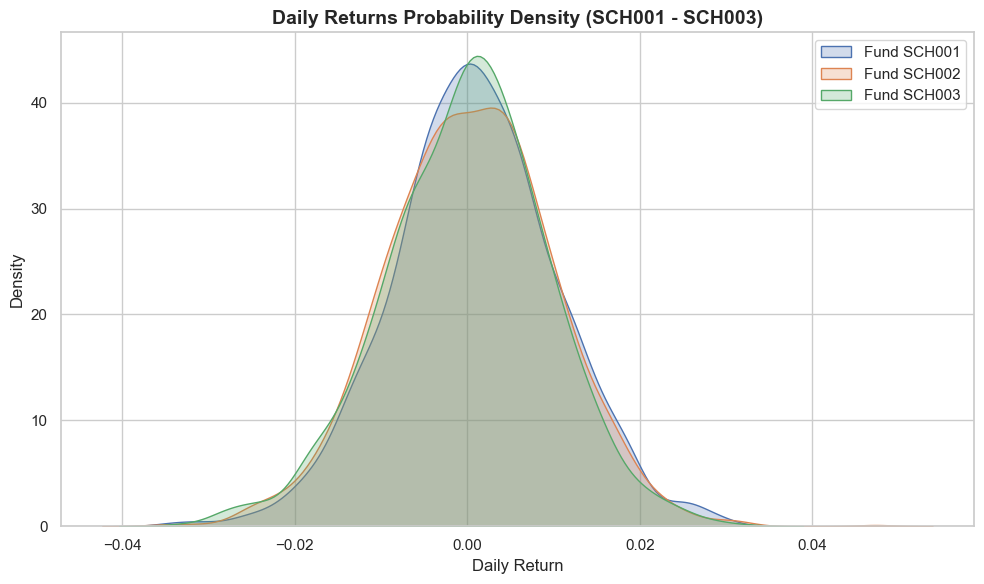

In [3]:
# Pivot NAV to get daily prices grid
df_prices = df_nav.pivot(index='date', columns='amfi_code', values='nav')
df_returns = df_prices.pct_change().dropna()

print("Daily returns calculated. Shape:", df_returns.shape)

# Plot returns distribution for first 3 funds
plt.figure(figsize=(10, 6))
for i in range(1, 4):
    sns.kdeplot(df_returns[f"SCH{str(i).zfill(3)}"], label=f"Fund SCH{str(i).zfill(3)}", fill=True, alpha=0.25)
plt.title("Daily Returns Probability Density (SCH001 - SCH003)", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/returns_distribution.png", bbox_inches='tight')
plt.show()

## 3. Trailing CAGR (1-Year, 3-Year, 5-Year)
We compute the Compound Annual Growth Rate (CAGR) for 1-year and 3-year periods. For the 5-year column, since our dataset contains ~4.5 years of history (Jan 2022 to Jun 2026), we use the maximum available historical timeline for our long-term metric.

$$CAGR = \left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1$$

In [4]:
latest_date = df_nav['date'].max()

def calculate_cagr(prices, years):
    start_date = latest_date - pd.DateOffset(years=years)
    # Find closest actual dates in price index
    actual_start = prices.index[prices.index >= start_date].min()
    actual_end = prices.index.max()
    
    if pd.isna(actual_start):
        return pd.Series(index=prices.columns, dtype=float)
        
    nav_start = prices.loc[actual_start]
    nav_end = prices.loc[actual_end]
    
    # Calculate years fraction
    n = (actual_end - actual_start).days / 365.25
    cagr = (nav_end / nav_start) ** (1.0 / n) - 1.0
    return cagr * 100.0 # return percentage

cagr_1y = calculate_cagr(df_prices, 1)
cagr_3y = calculate_cagr(df_prices, 3)

# 5-Year CAGR proxy (Full Available History: Jan 2022 to Jun 2026)
start_date_full = df_prices.index.min()
end_date_full = df_prices.index.max()
n_full = (end_date_full - start_date_full).days / 365.25
cagr_5y = ((df_prices.loc[end_date_full] / df_prices.loc[start_date_full]) ** (1.0 / n_full) - 1.0) * 100.0

df_cagr = pd.DataFrame({
    "cagr_1y": cagr_1y,
    "cagr_3y": cagr_3y,
    "cagr_5y": cagr_5y
})
print("CAGR trailing table successfully created. Head:")
print(df_cagr.head())

CAGR trailing table successfully created. Head:
             cagr_1y    cagr_3y    cagr_5y
amfi_code                                 
SCH001     36.256885  47.473733  34.070201
SCH002     38.196848  10.630413  11.195572
SCH003     31.216110  -4.553581  -2.841948
SCH004      3.618837  -4.183974  -3.211678
SCH005     20.813386  12.501712  11.331020


## 4. Sharpe & Sortino Ratios
We compute the risk-adjusted returns using Sharpe and Sortino formulas:
* **Sharpe Ratio**: Annualized return minus Risk-Free rate (6.5%) divided by annualized return volatility.
  $$Sharpe = \frac{R_p - R_f}{Std(R_{p,daily}) \times \sqrt{252}}$$
* **Sortino Ratio**: Same numerator, but denominator uses the downside deviation (daily returns standard deviation calculated for negative return days only).
  $$Sortino = \frac{R_p - R_f}{Downside\,Volatility \times \sqrt{252}}$$

In [5]:
rf = 6.5 # 6.5% annual RBI repo rate proxy
rf_daily = rf / 100.0 / 252.0 # daily risk free rate

sharpe_ratios = []
sortino_ratios = []

for col in df_prices.columns:
    rets = df_returns[col]
    ann_return = df_cagr.loc[col, "cagr_3y"]
    
    # Annualized daily volatility
    ann_std = rets.std() * np.sqrt(252) * 100.0
    sharpe = (ann_return - rf) / ann_std
    sharpe_ratios.append(sharpe)
    
    # Downside volatility: returns relative to daily risk free rate
    downside_diffs = np.minimum(rets - rf_daily, 0.0)
    downside_dev = np.sqrt(np.mean(downside_diffs ** 2)) * np.sqrt(252) * 100.0
    sortino = (ann_return - rf) / downside_dev if downside_dev > 0 else np.nan
    sortino_ratios.append(sortino)
    
df_ratios = pd.DataFrame({
    "sharpe_ratio": sharpe_ratios,
    "sortino_ratio": sortino_ratios
}, index=df_prices.columns)

print("Sharpe and Sortino ratios successfully calculated. Head:")
print(df_ratios.head())

Sharpe and Sortino ratios successfully calculated. Head:
           sharpe_ratio  sortino_ratio
amfi_code                             
SCH001         2.710872       4.031486
SCH002         0.268412       0.382394
SCH003        -0.730449      -0.988091
SCH004        -0.689960      -0.960553
SCH005         0.375495       0.537352


## 5. Alpha & Beta Calculations
We perform OLS linear regression of daily fund returns on daily Nifty 100 returns (using `scipy.stats.linregress`) to determine the fund's sensitivity to market movements:
* **Beta** (Slope): Sensitivity to market returns.
* **Alpha** (Annualized Intercept): Outperformance relative to the benchmark.
  $$Alpha = Intercept \times 252 \times 100$$

In [6]:
# Daily Nifty 100 returns
df_bench_prices = df_bench.set_index('date')
df_bench_returns = df_bench_prices['nifty_100'].pct_change().dropna()

# Intersection dates
common_dates = df_returns.index.intersection(df_bench_returns.index)

alphas = []
betas = []
r_squareds = []
p_values = []

for col in df_prices.columns:
    y = df_returns.loc[common_dates, col]
    x = df_bench_returns.loc[common_dates]
    
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    alphas.append(intercept * 252 * 100) # annualized and as percentage
    betas.append(slope)
    r_squareds.append(r_value ** 2)
    p_values.append(p_value)
    
df_alpha_beta = pd.DataFrame({
    "alpha": alphas,
    "beta": betas,
    "r_squared": r_squareds,
    "p_value": p_values
}, index=df_prices.columns)

# Save to data/processed
df_alpha_beta.to_csv("data/processed/alpha_beta.csv")
print("Alpha/Beta calculations saved to data/processed/alpha_beta.csv. Head:")
print(df_alpha_beta.head())

Alpha/Beta calculations saved to data/processed/alpha_beta.csv. Head:
               alpha      beta  r_squared   p_value
amfi_code                                          
SCH001     21.156441  0.016059   0.000172  0.596398
SCH002      7.884860  0.045077   0.001309  0.144155
SCH003     -0.223895 -0.045001   0.001349  0.138160
SCH004     -0.144937 -0.066034   0.002774  0.033426
SCH005      8.601766  0.005908   0.000021  0.853835


## 6. Maximum Drawdown & Date Ranges
We calculate peak-to-trough drawdowns for each scheme to identify historical maximum losses and identify the worst drawdown dates.

$$Drawdown = \frac{NAV_t}{\max(NAV_{1..t})} - 1$$

In [7]:
max_dds = []
worst_dd_start_dates = []
worst_dd_trough_dates = []

for col in df_prices.columns:
    prices = df_prices[col]
    running_max = prices.cummax()
    drawdown = (prices / running_max) - 1.0
    
    max_dd = drawdown.min()
    max_dds.append(max_dd * 100.0) # percent
    
    # Worst drawdown date range
    trough_date = drawdown.idxmin()
    peak_date = prices.loc[:trough_date].idxmax()
    
    worst_dd_start_dates.append(peak_date.strftime("%Y-%m-%d"))
    worst_dd_trough_dates.append(trough_date.strftime("%Y-%m-%d"))

df_drawdown = pd.DataFrame({
    "max_drawdown": max_dds,
    "worst_dd_start": worst_dd_start_dates,
    "worst_dd_trough": worst_dd_trough_dates
}, index=df_prices.columns)

print("Max drawdown index completed. Head:")
print(df_drawdown.head())

Max drawdown index completed. Head:
           max_drawdown worst_dd_start worst_dd_trough
amfi_code                                             
SCH001       -26.014989     2024-05-17      2025-01-04
SCH002       -41.975652     2024-04-17      2025-06-25
SCH003       -52.299172     2022-07-03      2024-09-09
SCH004       -32.209797     2022-05-16      2025-08-06
SCH005       -30.617602     2023-09-05      2024-07-22


## 7. Fund Scorecard (0-100)
We compile a composite index score ranking all 40 funds:
* **30%** × 3-Year CAGR rank
* **25%** × Sharpe Ratio rank
* **20%** × Alpha rank
* **15%** × Expense Ratio rank (inverse - lower is better)
* **10%** × Max Drawdown rank (inverse - less negative drawdown is better)

In [8]:
df_scorecard = df_cagr.join(df_ratios).join(df_alpha_beta).join(df_drawdown)
df_scorecard = df_scorecard.join(df_perf.set_index('amfi_code'))

# Calculate percentile ranks (0 to 1)
rank_3y = df_scorecard['cagr_3y'].rank(pct=True)
rank_sharpe = df_scorecard['sharpe_ratio'].rank(pct=True)
rank_alpha = df_scorecard['alpha'].rank(pct=True)
rank_er = df_scorecard['expense_ratio'].rank(pct=True, ascending=False) # lower is better
rank_dd = df_scorecard['max_drawdown'].rank(pct=True) # less negative is better

df_scorecard['composite_score'] = (
    0.30 * rank_3y +
    0.25 * rank_sharpe +
    0.20 * rank_alpha +
    0.15 * rank_er +
    0.10 * rank_dd
) * 100.0

df_scorecard['composite_score'] = np.round(df_scorecard['composite_score'], 2)
df_scorecard = df_scorecard.sort_values(by='composite_score', ascending=False)
df_scorecard['final_rank'] = range(1, len(df_scorecard) + 1)

# Save to data/processed
df_scorecard.to_csv("data/processed/fund_scorecard.csv")
print("Scorecard generated and saved to data/processed/fund_scorecard.csv. Top 5 Funds:")
print(df_scorecard[['cagr_3y', 'sharpe_ratio', 'alpha', 'expense_ratio', 'max_drawdown', 'composite_score', 'final_rank']].head(5))

Scorecard generated and saved to data/processed/fund_scorecard.csv. Top 5 Funds:
             cagr_3y  sharpe_ratio      alpha  expense_ratio  max_drawdown  \
amfi_code                                                                    
SCH001     47.473733      2.710872  21.156441        0.00450    -26.014989   
SCH011     29.681768      1.520154  16.067887        0.00215    -29.270631   
SCH019     22.500107      1.025132  13.166261        0.00553    -20.317042   
SCH037     44.572946      2.466433  19.643614        0.02293    -17.215500   
SCH016     30.381596      1.588017  14.157070        0.01943    -21.498105   

           composite_score  final_rank  
amfi_code                               
SCH001                97.0           1  
SCH011                92.0           2  
SCH019                85.5           3  
SCH037                85.0           4  
SCH016                83.0           5  


## 8. Benchmark Comparison Chart & Tracking Error
We extract the Top 5 funds from our scorecard, plot their 3-year trailing cumulative performance against Nifty 50 and Nifty 100, and calculate their annualized tracking error:

$$Tracking\,Error = Std(R_{p,daily} - R_{benchmark,daily}) \times \sqrt{252}$$

Top 5 Funds selected for chart: ['SCH001', 'SCH011', 'SCH019', 'SCH037', 'SCH016']

--- Annualized Tracking Error against Nifty 100 ---
• SCH001: 20.13%
• SCH011: 20.47%
• SCH019: 20.16%
• SCH037: 20.45%
• SCH016: 19.81%



Exported chart: reports/figures/benchmark_comparison_chart.png


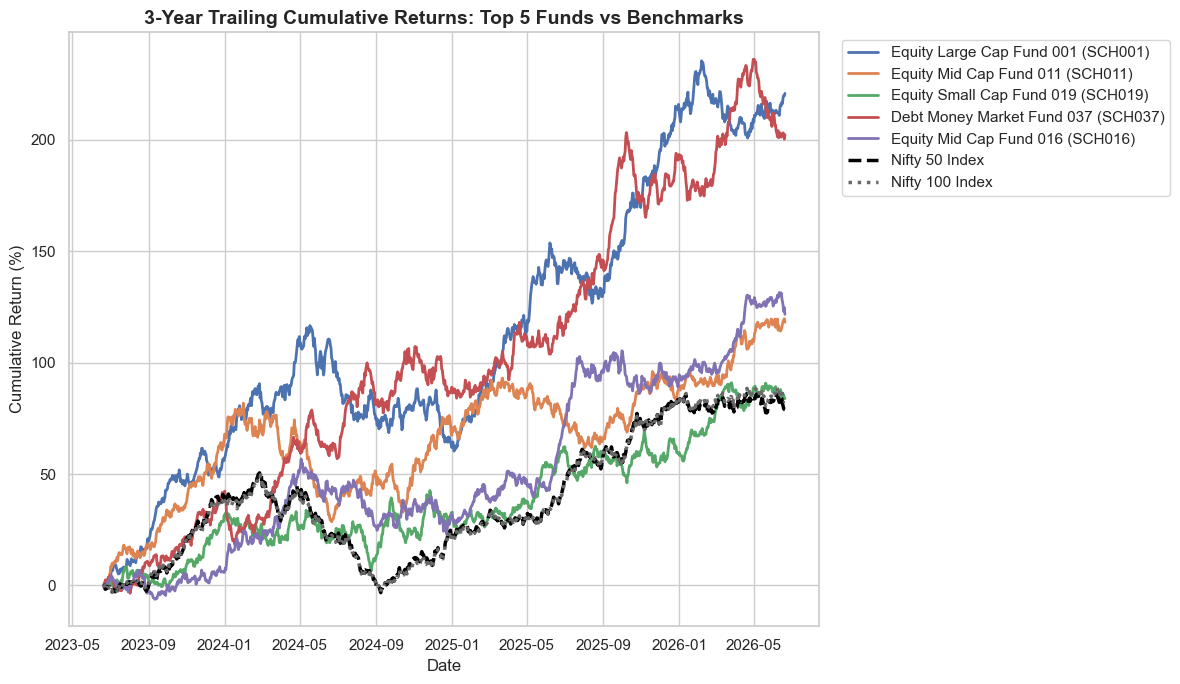

In [9]:
top_5_codes = df_scorecard.index[:5].tolist()
print("Top 5 Funds selected for chart:", top_5_codes)

three_years_ago = latest_date - pd.DateOffset(years=3)
valid_dates = df_prices.index[df_prices.index >= three_years_ago]

df_top_5_prices = df_prices.loc[valid_dates, top_5_codes]
df_bench_3y = df_bench_prices.loc[valid_dates, ['nifty_50', 'nifty_100']]

# Calculate cumulative returns
df_cum_funds = (df_top_5_prices / df_top_5_prices.iloc[0] - 1.0) * 100.0
df_cum_bench = (df_bench_3y / df_bench_3y.iloc[0] - 1.0) * 100.0

plt.figure(figsize=(12, 7))
for col in top_5_codes:
    fund_name = df_nav[df_nav['amfi_code'] == col]['scheme_name'].iloc[0]
    plt.plot(df_cum_funds.index, df_cum_funds[col], label=f"{fund_name} ({col})", linewidth=2)
    
plt.plot(df_cum_bench.index, df_cum_bench['nifty_50'], label="Nifty 50 Index", color='black', linestyle='--', linewidth=2.5)
plt.plot(df_cum_bench.index, df_cum_bench['nifty_100'], label="Nifty 100 Index", color='dimgray', linestyle=':', linewidth=2.5)

plt.title("3-Year Trailing Cumulative Returns: Top 5 Funds vs Benchmarks", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Return (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Calculate tracking errors against Nifty 100
df_returns_3y = df_returns.loc[valid_dates[1:]]
df_bench_returns_3y = df_bench_returns.loc[valid_dates[1:]]

print("\n--- Annualized Tracking Error against Nifty 100 ---")
for col in top_5_codes:
    active_return = df_returns_3y[col] - df_bench_returns_3y
    tracking_error = active_return.std() * np.sqrt(252) * 100.0
    print(f"• {col}: {tracking_error:.2f}%")

plt.tight_layout()
plt.savefig("reports/figures/benchmark_comparison_chart.png", bbox_inches='tight')
print("\nExported chart: reports/figures/benchmark_comparison_chart.png")
plt.show()